In [2]:
from pathlib import Path
import sys
from dataclasses import dataclass

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

We consider the open XX chain

$$
H_{\mathrm{XX}}
=
\frac{J}{2}
\sum_{j=1}^{L-1}
\left(
\sigma_j^x\sigma_{j+1}^x
+
\sigma_j^y\sigma_{j+1}^y
\right).
$$

The boundary-driven Lindbladian is

$$
\mathcal L_\mu[\rho]
=
-i[H_{\mathrm{XX}},\rho]
+
\Gamma(1+\mu)\mathcal D[\sigma_1^+]\rho
+
\Gamma(1-\mu)\mathcal D[\sigma_1^-]\rho
+
\Gamma(1-\mu)\mathcal D[\sigma_L^+]\rho
+
\Gamma(1+\mu)\mathcal D[\sigma_L^-]\rho,
$$

where

$$
\mathcal D[L]\rho
=
L\rho L^\dagger
-\frac12\{L^\dagger L,\rho\}.
$$

The left reservoir favours
$\langle\sigma_1^z\rangle=+\mu$, while the right reservoir favours
$\langle\sigma_L^z\rangle=-\mu$. The imbalance therefore drives a
spin current through the chain.

In [3]:
# ============================================================
# Boundary-driven XX chain: exact diagonalisation
# ============================================================

# --------------------
# Tensor-product helpers
# --------------------

def kron_all(operators):
    result = np.array([[1.0]], dtype=complex)

    for operator in operators:
        result = np.kron(result, operator)

    return result


def site_operator(operator, site, L):
    """
    Embed a one-site operator at site=0,...,L-1.
    """
    operators = [Pauli.I2] * L
    operators[site] = operator

    return kron_all(operators)


def bond_operator(A, B, site, L):
    """
    Embed A_site B_{site+1}.
    """
    operators = [Pauli.I2] * L
    operators[site] = A
    operators[site + 1] = B

    return kron_all(operators)


# --------------------
# XX-chain operators
# --------------------

def xx_chain_operators(L, J):
    sx = [
        site_operator(Pauli.sx, j, L)
        for j in range(L)
    ]
    sy = [
        site_operator(Pauli.sy, j, L)
        for j in range(L)
    ]
    sz = [
        site_operator(Pauli.sz, j, L)
        for j in range(L)
    ]

    sp = [
        site_operator(Pauli.sp, j, L)
        for j in range(L)
    ]
    sm = [
        site_operator(Pauli.sm, j, L)
        for j in range(L)
    ]

    H = sum(
        0.5 * J * (
            sx[j] @ sx[j + 1]
            + sy[j] @ sy[j + 1]
        )
        for j in range(L - 1)
    )

    # Current from site j to site j+1
    current = [
        J * (
            sx[j] @ sy[j + 1]
            - sy[j] @ sx[j + 1]
        )
        for j in range(L - 1)
    ]

    return H, sx, sy, sz, sp, sm, current

In [71]:
def hermitise(A):
    return 0.5 * (A + A.conj().T)


#Complete set of operators between the eigenstates of the rho_ss. 
def full_XX_transition_basis(
    builder,
    model,
    mu_reference,
    *,
    derivative_step=1e-5,
):
    """
    Construct all |m><n|, m != n, in the common eigenbasis of
    rho_ss(mu) and partial_mu rho_ss.

    Returns
    -------
    jump_operators : list of ndarray
        Complete directed-transition basis.

    labels : list of tuple
        labels[k] = (m, n) means |m><n|.

    U : ndarray
        Columns are the chosen NESS eigenvectors.

    rho_reference : ndarray
        Steady state at mu_reference.

    drho_reference : ndarray
        Numerical derivative at mu_reference.
    """
    rho_reference = hermitise(
        get_steady_state(
            builder,
            model,
            mu_reference,
        )
    )

    rho_plus = hermitise(
        get_steady_state(
            builder,
            model,
            mu_reference + derivative_step,
        )
    )

    rho_minus = hermitise(
        get_steady_state(
            builder,
            model,
            mu_reference - derivative_step,
        )
    )

    drho_reference = (
        rho_plus - rho_minus
    ) / (2.0 * derivative_step)

    # Since rho(mu) = rho_0 + mu R for this protocol,
    # diagonalising drho/dmu selects the fixed eigenbasis.
    _, U = np.linalg.eigh(
        hermitise(drho_reference)
    )

    dim = rho_reference.shape[0]

    jump_operators = []
    labels = []

    for m in range(dim):
        ket_m = U[:, m]

        for n in range(dim):
            if m == n:
                continue

            ket_n = U[:, n]

            L_mn = np.outer(
                ket_m,
                ket_n.conj(),
            )

            jump_operators.append(L_mn)
            labels.append((m, n))

    # Check that the chosen basis also diagonalises rho_ss.
    rho_in_basis = U.conj().T @ rho_reference @ U

    offdiagonal = (
        rho_in_basis
        - np.diag(np.diag(rho_in_basis))
    )

    print(
        "||offdiag(U^dagger rho U)||:",
        np.linalg.norm(offdiagonal, ord="fro"),
    )
    print(
        "Number of jump operators:",
        len(jump_operators),
    )

    return (
        jump_operators,
        labels,
        U,
        rho_reference,
        drho_reference,
    )


def natural_mode_jumps(
    sm_ops,
    sp_ops,
    *,
    sz_ops=None,
    use_jw_strings=False,
):
    """
    Construct natural-mode gain and loss jump operators for Gamma = J.

    If use_jw_strings=False:

        d_alpha^- = sum_j u_{j,alpha} sigma_j^-

    If use_jw_strings=True:

        d_alpha^- = sum_j u_{j,alpha} c_j

    where

        c_j = (prod_{ell < j} sigma_ell^z) sigma_j^-.

    The gain operators are the Hermitian conjugates:

        d_alpha^+ = (d_alpha^-)^dagger.

    Parameters
    ----------
    sm_ops, sp_ops : sequence of ndarray
        Embedded many-body lowering and raising operators on each site.

    sz_ops : sequence of ndarray, optional
        Embedded sigma_z operators. Required when
        use_jw_strings=True.

    use_jw_strings : bool, optional
        If False, construct string-free collective spin operators.
        If True, construct the exact fermionic natural modes.

    Returns
    -------
    jump_operators : list of ndarray
        Ordered as

            [d_1^-, d_1^+, d_2^-, d_2^+, ...]

    labels : list of str
        Labels for the operators.

    coefficients : ndarray, shape (L, L)
        coefficients[alpha, j] is the coefficient multiplying the
        site-j lowering operator in d_alpha^-.

    site_annihilation_ops : list of ndarray
        The operators being combined: either sigma_j^- or c_j.
    """
    sm_ops = tuple(
        np.asarray(op, dtype=np.complex128)
        for op in sm_ops
    )
    sp_ops = tuple(
        np.asarray(op, dtype=np.complex128)
        for op in sp_ops
    )

    L = len(sm_ops)

    if L == 0:
        raise ValueError("At least one site is required.")

    if len(sp_ops) != L:
        raise ValueError(
            "sm_ops and sp_ops must have the same length."
        )

    shape = sm_ops[0].shape

    if len(shape) != 2 or shape[0] != shape[1]:
        raise ValueError(
            "The supplied operators must be square matrices."
        )

    if any(op.shape != shape for op in (*sm_ops, *sp_ops)):
        raise ValueError(
            "All spin operators must have the same shape."
        )

    # -------------------------------------------------------
    # Choose the site operators to combine
    # -------------------------------------------------------
    if use_jw_strings:
        if sz_ops is None:
            raise ValueError(
                "sz_ops is required when use_jw_strings=True."
            )

        sz_ops = tuple(
            np.asarray(op, dtype=np.complex128)
            for op in sz_ops
        )

        if len(sz_ops) != L:
            raise ValueError(
                "sz_ops must contain one operator per site."
            )

        if any(op.shape != shape for op in sz_ops):
            raise ValueError(
                "Every sz operator must have the same shape "
                "as the raising and lowering operators."
            )

        site_annihilation_ops = []
        site_creation_ops = []

        # parity_string = product_{ell < j} sigma_ell^z
        parity_string = np.eye(shape[0], dtype=np.complex128)

        for j in range(L):
            c_j = parity_string @ sm_ops[j]
            cdag_j = parity_string @ sp_ops[j]

            site_annihilation_ops.append(c_j)
            site_creation_ops.append(cdag_j)

            # Include sigma_j^z in the string for all later sites.
            parity_string = parity_string @ sz_ops[j]

        mode_name = "fermionic"
    else:
        site_annihilation_ops = list(sm_ops)
        site_creation_ops = list(sp_ops)
        mode_name = "spin"

    # -------------------------------------------------------
    # Natural-mode coefficients for Gamma = J
    # -------------------------------------------------------
    sites = np.arange(1, L + 1)

    jump_operators = []
    labels = []
    coefficients = []

    for alpha in range(1, L + 1):
        k_alpha = (2 * alpha - 1) * np.pi / (2 * L)

        coeff = (
            np.sqrt(2.0 / L)
            * ((-1j) ** (sites - 1))
            * np.cos((sites - 0.5) * k_alpha)
        )

        d_minus = np.zeros(shape, dtype=np.complex128)
        d_plus = np.zeros(shape, dtype=np.complex128)

        for j in range(L):
            d_minus += (
                coeff[j] * site_annihilation_ops[j]
            )
            d_plus += (
                coeff[j].conjugate()
                * site_creation_ops[j]
            )

        # Suppress accumulated floating-point asymmetry.
        d_plus = 0.5 * (
            d_plus + d_minus.conj().T
        )

        coefficients.append(coeff)

        jump_operators.extend([
            d_minus,
            d_plus,
        ])

        labels.extend([
            f"{mode_name}_d_minus_{alpha}",
            f"{mode_name}_d_plus_{alpha}",
        ])

    return (
        jump_operators,
        labels,
        np.asarray(coefficients),
        site_annihilation_ops,
    )

16
Minimum parameter spacing: 0.008749999999999813
Maximum |sdot|: 3.5
Maximum |x|: 9.331751081711029e-14
Maximum gamma: 2.567414485203394
Maximum physical Hamiltonian coefficient: 3.26611287859886e-13
Maximum physical CD jump rate: 8.98595069821188
Maximum variational residual: 0.5251216571873395


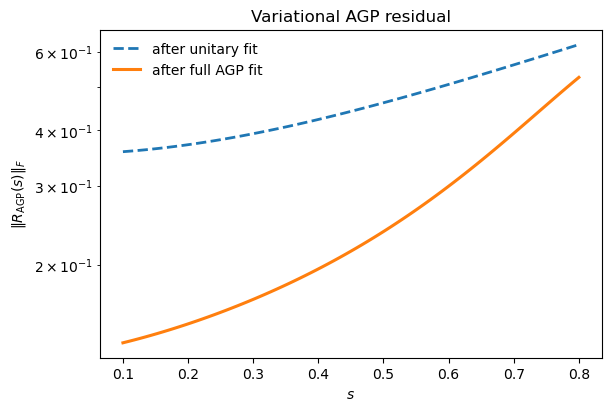

16


In [88]:
# ============================================================
# Model parameters
# ============================================================

L = 4                 # start small for dense ED
dim = 2**L

J = 1.0
Gamma = 1.0

mu0 = 0.1
mu1 = 0.8

tau = 0.2
nsteps = 81

times = np.linspace(0.0, tau, nsteps)

H_XX, sx_ops, sy_ops, sz_ops, sp_ops, sm_ops, current_ops = (
    xx_chain_operators(L, J)
)


# ============================================================
# Parameter-dependent physical Lindbladian L(mu)
# ============================================================

def H_of_mu(mu):
    return H_XX


def jumps_of_mu(mu):
    return [
        # Left reservoir: favours +mu
        Jump(sp_ops[0], Gamma * (1.0 + mu)),
        Jump(sm_ops[0], Gamma * (1.0 - mu)),

        # Right reservoir: favours -mu
        Jump(sp_ops[-1], Gamma * (1.0 - mu)),
        Jump(sm_ops[-1], Gamma * (1.0 + mu)),
    ]


model_XX = LindbladModel2LS(
    H_of_mu,
    jumps_of_mu,
)


# ============================================================
# Linear boundary-bias protocol
# ============================================================

def mu_of_t(t):
    return mu0 + (mu1 - mu0) * t / tau


def mudot_of_t(t):
    return (mu1 - mu0) / tau


# ============================================================
# Variational AGP basis
# ============================================================

hamiltonians_XX = (sz_ops)
# (
#     sz_ops
#     + current_ops
# )

# single_site_families = [
#     sx_ops,
#     sy_ops,
#     sz_ops,
# ]

# hamiltonians_XX = []

# # All one-site Pauli operators
# for operator_family in single_site_families:
#     hamiltonians_XX.extend(operator_family)

# # All nearest-neighbour Pauli products
# for j in range(L - 1):
#     for left_family in single_site_families:
#         for right_family in single_site_families:
#             hamiltonians_XX.append(
#                 left_family[j] @ right_family[j + 1]
#             )

# print("Number of Hamiltonian basis terms:", len(hamiltonians_XX))

# #All of the possible jump operators connecting states
# builder_XX = LiouvillianBuilder(
#     dim=dim,
# )

# mu_reference = 0.5 * (
#     mu0 + mu1
# )

# (
#     jump_operators_XX,
#     jump_labels_XX,
#     U_XX,
#     rho_reference,
#     drho_reference,
# ) = full_XX_transition_basis(
#     builder=builder_XX,
#     model=model_XX,
#     mu_reference=mu_reference,
# )




# # Full set of operators in the language of d,d^dagger
# jump_operators_XX, jump_labels_XX, mode_coefficients, _ = (
#     natural_mode_jumps(sm_ops, sp_ops, sz_ops=sz_ops, use_jw_strings=True)
# )

# print("Number of jump operators:", len(jump_operators_XX))
# print(jump_labels_XX)


jump_operators_XX = []

for j in range(L - 1):
    A = sm_ops[j]
    B = sz_ops[j] @ sm_ops[j + 1]

    for phase in [1.0j, -1.0j]: #[1.0, -1.0, 1.0j, -1.0j]
        L_minus = (A + phase * B) / np.sqrt(2.0)

        jump_operators_XX.extend([
            L_minus,
            L_minus.conj().T,
        ])


# jump_operators_XX = []

# # Local raising, lowering and dephasing on every site
# # jump_operators_XX.extend(sp_ops)
# # jump_operators_XX.extend(sm_ops)
# # jump_operators_XX.extend(sz_ops)

# # Chiral collective jumps on every bond.
# # These can directly produce imaginary coherences and spin current.
# for j in range(L - 1):
#     jump_operators_XX.extend([
#         # Lowering-type chiral jumps
#         (
#             sm_ops[j]
#             + 1j * sm_ops[j + 1]
#         ) / np.sqrt(2.0),

#         (
#             sm_ops[j]
#             - 1j * sm_ops[j + 1]
#         ) / np.sqrt(2.0),

#         # Raising-type chiral jumps
#         (
#             sp_ops[j]
#             + 1j * sp_ops[j + 1]
#         ) / np.sqrt(2.0),

#         (
#             sp_ops[j]
#             - 1j * sp_ops[j + 1]
#         ) / np.sqrt(2.0),
#     ])


# #Add the boundary jump operators
# jump_operators_XX.extend([
#     sp_ops[0],
#     sm_ops[0],
#     sp_ops[-1],
#     sm_ops[-1],
# ])

# jump_operators_XX.extend([
#     # End-to-end collective lowering
#     (
#         sm_ops[0] + sm_ops[2]
#     ) / np.sqrt(2.0),

#     (
#         sm_ops[0] - sm_ops[2]
#     ) / np.sqrt(2.0),

#     # End-to-end collective raising
#     (
#         sp_ops[0] + sp_ops[2]
#     ) / np.sqrt(2.0),

#     (
#         sp_ops[0] - sp_ops[2]
#     ) / np.sqrt(2.0),
# ])

# print("Number of dissipative basis terms:", len(jump_operators_XX))

# ============================================================
# Approximate-CD evolution
# ============================================================

t, traj_cd, rho_cd, rho_ss, agp_data = approx_CD_trajectory(
    model=model_XX,
    s_of_t=mu_of_t,
    times=times,
    hamiltonians=hamiltonians_XX,
    jump_operators=jump_operators_XX,
    dim=dim,
    sdot_of_t=mudot_of_t,
    lam_unitary=1e-10,
    lam_dissipative=1e-10,
    plot_residual=True,
    residual_logscale=True,
    verbose=True,
)

# ============================================================
# Bare evolution under L(mu(t))
# ============================================================

bare_model_XX = LindbladModel2LS(
    lambda tt: model_XX.H(mu_of_t(tt)),
    lambda tt: model_XX.jumps(mu_of_t(tt)),
)

builder_XX = LiouvillianBuilder(dim=dim)

traj_bare, rho_bare = evolve_density_matrices(
    bare_model_XX,
    builder_XX,
    rho_ss[0],
    t,
)

Number of jump operators: 12
 0: $L^{-,+i}_{1,2}$; bond=1; phase=+i; type=lowering; alpha=0.30
 1: $L^{+,+i}_{1,2}$; bond=1; phase=+i; type=raising; alpha=0.30
 2: $L^{-,-i}_{1,2}$; bond=1; phase=-i; type=lowering; alpha=0.30
 3: $L^{+,-i}_{1,2}$; bond=1; phase=-i; type=raising; alpha=0.30
 4: $L^{-,+i}_{2,3}$; bond=2; phase=+i; type=lowering; alpha=0.65
 5: $L^{+,+i}_{2,3}$; bond=2; phase=+i; type=raising; alpha=0.65
 6: $L^{-,-i}_{2,3}$; bond=2; phase=-i; type=lowering; alpha=0.65
 7: $L^{+,-i}_{2,3}$; bond=2; phase=-i; type=raising; alpha=0.65
 8: $L^{-,+i}_{3,4}$; bond=3; phase=+i; type=lowering; alpha=1.00
 9: $L^{+,+i}_{3,4}$; bond=3; phase=+i; type=raising; alpha=1.00
10: $L^{-,-i}_{3,4}$; bond=3; phase=-i; type=lowering; alpha=1.00
11: $L^{+,-i}_{3,4}$; bond=3; phase=-i; type=raising; alpha=1.00


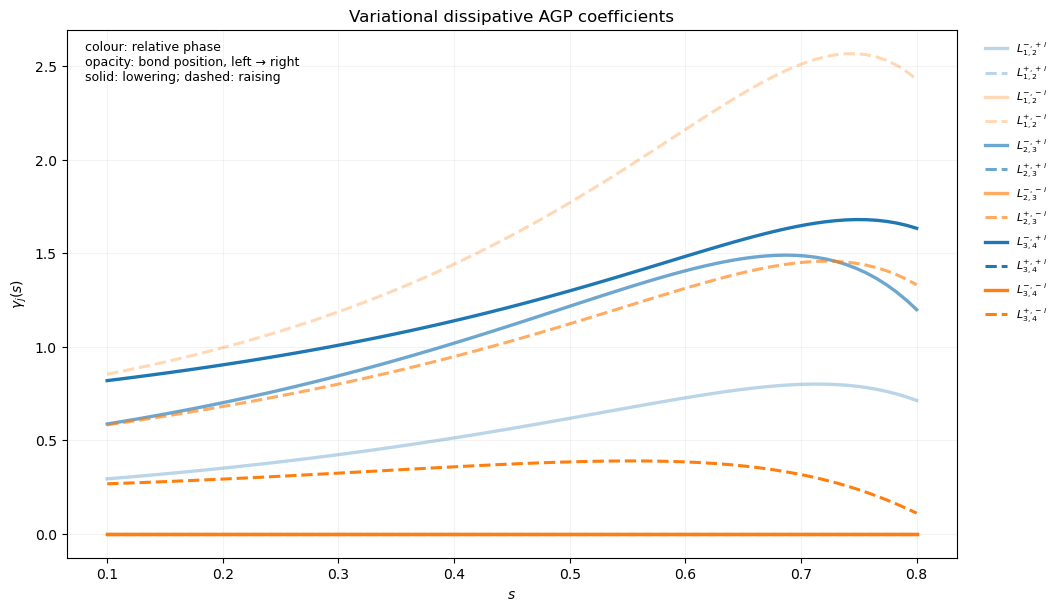

In [90]:
# ============================================================
# Bond-local parity-dressed jump operators, labels and styles
# ============================================================

jump_operators_XX = []
jump_labels_XX = []
jump_plot_styles_XX = []

# Colour is fixed by the relative phase.
phase_data = [
    (1.0j, r"+i", "tab:blue"),
    (-1.0j, r"-i", "tab:orange"),
]

number_bonds = L - 1

# Opacity increases from the left edge to the right edge.
if number_bonds == 1:
    bond_opacities = np.array([1.0])
else:
    bond_opacities = np.linspace(
        0.30,
        1.00,
        number_bonds,
    )

for j in range(number_bonds):
    A = sm_ops[j]
    B = sz_ops[j] @ sm_ops[j + 1]

    alpha = bond_opacities[j]

    for phase, phase_label, colour in phase_data:
        L_minus = (
            A + phase * B
        ) / np.sqrt(2.0)

        L_plus = L_minus.conj().T

        jump_operators_XX.extend([
            L_minus,
            L_plus,
        ])

        jump_labels_XX.extend([
            (
                rf"$L^{{-,{phase_label}}}_"
                rf"{{{j+1},{j+2}}}$"
            ),
            (
                rf"$L^{{+,{phase_label}}}_"
                rf"{{{j+1},{j+2}}}$"
            ),
        ])

        jump_plot_styles_XX.extend([
            {
                "color": colour,
                "alpha": alpha,
                "linestyle": "-",
                "linewidth": 2.4,
                "bond": j,
                "phase": phase_label,
                "type": "lowering",
            },
            {
                "color": colour,
                "alpha": alpha,
                "linestyle": "--",
                "linewidth": 2.2,
                "bond": j,
                "phase": phase_label,
                "type": "raising",
            },
        ])

print("Number of jump operators:", len(jump_operators_XX))

for index, (label, style) in enumerate(
    zip(jump_labels_XX, jump_plot_styles_XX)
):
    print(
        f"{index:2d}: {label}; "
        f"bond={style['bond'] + 1}; "
        f"phase={style['phase']}; "
        f"type={style['type']}; "
        f"alpha={style['alpha']:.2f}"
    )


# ============================================================
# Plot all fitted AGP jump rates
# ============================================================

gamma_grid = np.asarray(
    agp_data["gamma"],
    dtype=float,
)

parameter_grid = np.asarray(
    agp_data.get(
        "s",
        np.arange(gamma_grid.shape[0]),
    ),
    dtype=float,
)

if gamma_grid.ndim != 2:
    raise ValueError(
        "agp_data['gamma'] must have shape "
        "(number_parameter_points, number_jump_operators)."
    )

if gamma_grid.shape[1] != len(jump_labels_XX):
    raise ValueError(
        f"Found {gamma_grid.shape[1]} fitted coefficients but "
        f"{len(jump_labels_XX)} jump labels."
    )

fig, ax = plt.subplots(
    figsize=(10.5, 6.0),
    constrained_layout=True,
)

for index, (label, style) in enumerate(
    zip(jump_labels_XX, jump_plot_styles_XX)
):
    ax.plot(
        parameter_grid,
        gamma_grid[:, index],
        label=label,
        color=style["color"],
        alpha=style["alpha"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
    )

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$\gamma_j(s)$")
ax.set_title("Variational dissipative AGP coefficients")

ax.text(
    0.02,
    0.98,
    "colour: relative phase\n"
    "opacity: bond position, left → right\n"
    "solid: lowering; dashed: raising",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

ax.grid(alpha=0.15)

ax.legend(
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
    fontsize=8,
    ncol=1,
)

plt.show()

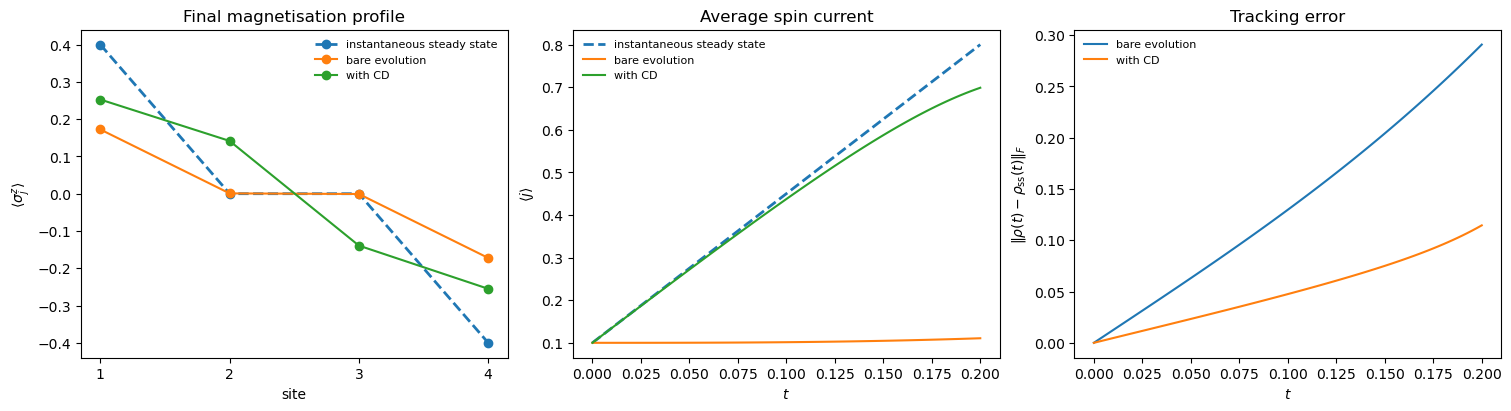

In [84]:
# ============================================================
# Observables
# ============================================================

def expectation_trajectory(rho_grid, operator):
    return np.array([
        np.trace(rho @ operator).real
        for rho in rho_grid
    ])


# Magnetisation at every site
mz_ss = np.column_stack([
    expectation_trajectory(rho_ss, op)
    for op in sz_ops
])

mz_bare = np.column_stack([
    expectation_trajectory(rho_bare, op)
    for op in sz_ops
])

mz_cd = np.column_stack([
    expectation_trajectory(rho_cd, op)
    for op in sz_ops
])

# Average current over all bonds
j_ss = np.mean(
    np.column_stack([
        expectation_trajectory(rho_ss, op)
        for op in current_ops
    ]),
    axis=1,
)

j_bare = np.mean(
    np.column_stack([
        expectation_trajectory(rho_bare, op)
        for op in current_ops
    ]),
    axis=1,
)

j_cd = np.mean(
    np.column_stack([
        expectation_trajectory(rho_cd, op)
        for op in current_ops
    ]),
    axis=1,
)

# Full density-matrix tracking errors
error_bare = np.array([
    np.linalg.norm(rho - target, ord="fro")
    for rho, target in zip(rho_bare, rho_ss)
])

error_cd = np.array([
    np.linalg.norm(rho - target, ord="fro")
    for rho, target in zip(rho_cd, rho_ss)
])

# ============================================================
# Comparison plot
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    constrained_layout=True,
)

# Final magnetisation profile
sites = np.arange(1, L + 1)

ax[0].plot(
    sites,
    mz_ss[-1],
    "o--",
    linewidth=2,
    label="instantaneous steady state",
)
ax[0].plot(
    sites,
    mz_bare[-1],
    "o-",
    label="bare evolution",
)
ax[0].plot(
    sites,
    mz_cd[-1],
    "o-",
    label="with CD",
)

ax[0].set_xlabel("site")
ax[0].set_ylabel(r"$\langle\sigma_j^z\rangle$")
ax[0].set_title("Final magnetisation profile")
ax[0].set_xticks(sites)
ax[0].legend(frameon=False, fontsize=8)

# Spin current
ax[1].plot(
    t,
    j_ss,
    "--",
    linewidth=2,
    label="instantaneous steady state",
)
ax[1].plot(
    t,
    j_bare,
    label="bare evolution",
)
ax[1].plot(
    t,
    j_cd,
    label="with CD",
)

ax[1].set_xlabel(r"$t$")
ax[1].set_ylabel(r"$\langle j\rangle$")
ax[1].set_title("Average spin current")
ax[1].legend(frameon=False, fontsize=8)

# State-tracking error
ax[2].plot(
    t,
    error_bare,
    label="bare evolution",
)
ax[2].plot(
    t,
    error_cd,
    label="with CD",
)

ax[2].set_xlabel(r"$t$")
ax[2].set_ylabel(
    r"$\|\rho(t)-\rho_{\rm ss}(t)\|_F$"
)
ax[2].set_title("Tracking error")
ax[2].legend(frameon=False, fontsize=8)

plt.show()

# Additional checks on validity

## Approximately uniform current on the bonds
We know that for the true solution, there should be uniform currents across all of the bonds. This is calculated below.

In [9]:
bond_currents_ss = np.column_stack([
    expectation_trajectory(rho_ss, op)
    for op in current_ops
])

print("Final steady-state bond currents:")
print(bond_currents_ss[-1])

Final steady-state bond currents:
[0.8 0.8]


## Checking diagonalisation
We want to check that we have the correct diagonalised operators for the correlation matrix.

In [64]:
def jordan_wigner_fermion_operators(sm_ops, sz_ops):
    """
    Construct Jordan-Wigner fermionic operators

        c_j = (prod_{ell < j} sigma_ell^z) sigma_j^-.

    Parameters
    ----------
    sm_ops : sequence of ndarray
        Many-body embedded sigma_j^- operators.

    sz_ops : sequence of ndarray
        Many-body embedded sigma_j^z operators.

    Returns
    -------
    c_ops : list of ndarray
        Fermionic annihilation operators c_j.

    cdag_ops : list of ndarray
        Fermionic creation operators c_j^dagger.
    """
    L = len(sm_ops)

    if len(sz_ops) != L:
        raise ValueError(
            "sm_ops and sz_ops must have the same length."
        )

    matrix_dim = sm_ops[0].shape[0]
    identity = np.eye(matrix_dim, dtype=np.complex128)

    c_ops = []
    parity_string = identity.copy()

    for j in range(L):
        c_j = parity_string @ sm_ops[j]

        c_ops.append(c_j)

        # The next site includes sigma_j^z in its JW string.
        parity_string = parity_string @ sz_ops[j]

    cdag_ops = [
        c.conj().T
        for c in c_ops
    ]

    return c_ops, cdag_ops

In [68]:
c_ops, cdag_ops = jordan_wigner_fermion_operators(
    sm_ops,
    sz_ops,
)
def covariance_matrix(rho, c_ops):
    L = len(c_ops)

    return np.array([
        [
            np.trace(
                rho
                @ c_ops[i].conj().T
                @ c_ops[j]
            )
            for j in range(L)
        ]
        for i in range(L)
    ])


C = covariance_matrix(rho_ss, c_ops)

In [70]:
# ============================================================
# Complete diagnostics for the natural-mode AGP construction
# ============================================================

import numpy as np
from scipy.linalg import expm


# ------------------------------------------------------------
# Basic dissipator convention:
#
# D[L](rho) = L rho L^dagger
#             - 1/2 {L^dagger L, rho}
# ------------------------------------------------------------

def dissipator_action(L, rho):
    LdagL = L.conj().T @ L

    return (
        L @ rho @ L.conj().T
        - 0.5 * (LdagL @ rho + rho @ LdagL)
    )


# ------------------------------------------------------------
# Jordan-Wigner operators
#
# c_j = (product_{ell<j} sigma_ell^z) sigma_j^-
# ------------------------------------------------------------

def jordan_wigner_fermion_operators(sm_ops, sz_ops):
    sm_ops = [
        np.asarray(op, dtype=np.complex128)
        for op in sm_ops
    ]
    sz_ops = [
        np.asarray(op, dtype=np.complex128)
        for op in sz_ops
    ]

    L = len(sm_ops)

    if len(sz_ops) != L:
        raise ValueError(
            "sm_ops and sz_ops must have the same length."
        )

    matrix_shape = sm_ops[0].shape

    if matrix_shape[0] != matrix_shape[1]:
        raise ValueError("Operators must be square matrices.")

    if any(op.shape != matrix_shape for op in sm_ops + sz_ops):
        raise ValueError(
            "All operators must have the same matrix shape."
        )

    identity = np.eye(
        matrix_shape[0],
        dtype=np.complex128,
    )

    c_ops = []
    parity_string = identity.copy()

    for j in range(L):
        c_j = parity_string @ sm_ops[j]
        c_ops.append(c_j)

        # Add sigma_j^z to the string for subsequent sites.
        parity_string = parity_string @ sz_ops[j]

    cdag_ops = [
        c.conj().T
        for c in c_ops
    ]

    return c_ops, cdag_ops


# ------------------------------------------------------------
# Verify canonical anticommutation relations
# ------------------------------------------------------------

def fermionic_anticommutation_errors(c_ops):
    L = len(c_ops)
    matrix_dim = c_ops[0].shape[0]

    identity = np.eye(
        matrix_dim,
        dtype=np.complex128,
    )

    maximum_cc_error = 0.0
    maximum_ccdag_error = 0.0

    for i in range(L):
        for j in range(L):
            # {c_i, c_j}
            anticommutator_cc = (
                c_ops[i] @ c_ops[j]
                + c_ops[j] @ c_ops[i]
            )

            maximum_cc_error = max(
                maximum_cc_error,
                np.linalg.norm(
                    anticommutator_cc,
                    ord="fro",
                ),
            )

            # {c_i, c_j^dagger}
            anticommutator_ccdag = (
                c_ops[i] @ c_ops[j].conj().T
                + c_ops[j].conj().T @ c_ops[i]
            )

            target = (
                identity
                if i == j
                else np.zeros_like(identity)
            )

            maximum_ccdag_error = max(
                maximum_ccdag_error,
                np.linalg.norm(
                    anticommutator_ccdag - target,
                    ord="fro",
                ),
            )

    return maximum_cc_error, maximum_ccdag_error


# ------------------------------------------------------------
# Covariance matrix
#
# C_ij = Tr(rho c_i^dagger c_j)
# ------------------------------------------------------------

def covariance_matrix(rho, c_ops):
    L = len(c_ops)

    return np.array([
        [
            np.trace(
                rho
                @ c_ops[i].conj().T
                @ c_ops[j]
            )
            for j in range(L)
        ]
        for i in range(L)
    ])


# ------------------------------------------------------------
# Construct numerical natural modes
#
# If C U = U diag(nu), then
#
# d_alpha = sum_j U[j,alpha] c_j.
# ------------------------------------------------------------

def numerical_natural_modes(rho, c_ops):
    C = covariance_matrix(rho, c_ops)

    # Enforce Hermiticity against numerical noise.
    C = 0.5 * (C + C.conj().T)

    occupations, eigenvectors = np.linalg.eigh(C)

    d_ops = []

    for alpha in range(len(c_ops)):
        d_alpha = np.zeros_like(
            c_ops[0],
            dtype=np.complex128,
        )

        for j in range(len(c_ops)):
            d_alpha += (
                eigenvectors[j, alpha] * c_ops[j]
            )

        d_ops.append(d_alpha)

    return C, occupations, eigenvectors, d_ops


# ------------------------------------------------------------
# Covariance in an arbitrary set of fermionic modes
# ------------------------------------------------------------

def mode_covariance_matrix(rho, mode_ops):
    number_modes = len(mode_ops)

    return np.array([
        [
            np.trace(
                rho
                @ mode_ops[alpha].conj().T
                @ mode_ops[beta]
            )
            for beta in range(number_modes)
        ]
        for alpha in range(number_modes)
    ])


# ------------------------------------------------------------
# Reconstruct the Gaussian state from natural occupations
#
# rho_G proportional to
#
# exp[-sum_alpha epsilon_alpha d_alpha^dagger d_alpha],
#
# epsilon_alpha = log[(1-nu_alpha)/nu_alpha].
# ------------------------------------------------------------

def reconstruct_gaussian_state(
    d_ops,
    occupations,
    *,
    cutoff=1e-13,
):
    occupations_safe = np.clip(
        np.real(occupations),
        cutoff,
        1.0 - cutoff,
    )

    gaussian_exponent = np.zeros_like(
        d_ops[0],
        dtype=np.complex128,
    )

    for d_alpha, occupation in zip(
        d_ops,
        occupations_safe,
    ):
        epsilon_alpha = np.log(
            (1.0 - occupation) / occupation
        )

        gaussian_exponent += (
            epsilon_alpha
            * d_alpha.conj().T
            @ d_alpha
        )

    rho_gaussian = expm(-gaussian_exponent)
    rho_gaussian /= np.trace(rho_gaussian)

    rho_gaussian = 0.5 * (
        rho_gaussian + rho_gaussian.conj().T
    )

    return rho_gaussian


# ------------------------------------------------------------
# Analytic natural-mode basis for Gamma = J
#
# Two phase conventions are returned because the correct one
# depends on the sign convention for C_ij and the hopping term.
# ------------------------------------------------------------

def analytic_natural_modes_gamma_equals_J(
    c_ops,
    *,
    phase_sign=1,
):
    """
    phase_sign = +1 gives i^(j-1).
    phase_sign = -1 gives (-i)^(j-1).
    """
    L = len(c_ops)
    sites = np.arange(1, L + 1)

    coefficients = []
    d_ops = []

    for alpha in range(1, L + 1):
        k_alpha = (
            (2 * alpha - 1)
            * np.pi
            / (2 * L)
        )

        coeff = (
            np.sqrt(2.0 / L)
            * ((phase_sign * 1j) ** (sites - 1))
            * np.cos(
                (sites - 0.5) * k_alpha
            )
        )

        d_alpha = np.zeros_like(
            c_ops[0],
            dtype=np.complex128,
        )

        for j in range(L):
            d_alpha += coeff[j] * c_ops[j]

        coefficients.append(coeff)
        d_ops.append(d_alpha)

    return (
        np.asarray(coefficients),
        d_ops,
    )


# ------------------------------------------------------------
# Generate partial_s rho from natural-mode gain/loss
# ------------------------------------------------------------

def natural_mode_dissipative_derivative(
    rho,
    partial_s_rho,
    c_ops,
    occupations,
    eigenvectors,
    d_ops,
    *,
    denominator_cutoff=1e-12,
):
    # Covariance derivative:
    #
    # partial_s C_ij
    # = Tr[(partial_s rho) c_i^dagger c_j].
    partial_s_C = covariance_matrix(
        partial_s_rho,
        c_ops,
    )

    partial_s_C = 0.5 * (
        partial_s_C + partial_s_C.conj().T
    )

    # Express partial_s C in the natural-mode basis.
    partial_s_C_natural = (
        eigenvectors.conj().T
        @ partial_s_C
        @ eigenvectors
    )

    partial_s_occupations = np.real(
        np.diag(partial_s_C_natural)
    )

    offdiagonal_derivative = (
        partial_s_C_natural
        - np.diag(
            np.diag(partial_s_C_natural)
        )
    )

    generated_derivative = np.zeros_like(
        rho,
        dtype=np.complex128,
    )

    gamma_minus = np.zeros(len(d_ops))
    gamma_plus = np.zeros(len(d_ops))

    jump_operators = []
    rates = []

    for alpha, (
        d_alpha,
        occupation,
        occupation_derivative,
    ) in enumerate(zip(
        d_ops,
        occupations,
        partial_s_occupations,
    )):
        occupation = float(np.real(occupation))

        if occupation_derivative < 0.0:
            if occupation < denominator_cutoff:
                raise ValueError(
                    f"Mode {alpha} has nu approximately zero "
                    "but requires a negative occupation derivative."
                )

            gamma_minus[alpha] = (
                -occupation_derivative / occupation
            )

        elif occupation_derivative > 0.0:
            if 1.0 - occupation < denominator_cutoff:
                raise ValueError(
                    f"Mode {alpha} has nu approximately one "
                    "but requires a positive occupation derivative."
                )

            gamma_plus[alpha] = (
                occupation_derivative
                / (1.0 - occupation)
            )

        generated_derivative += (
            gamma_minus[alpha]
            * dissipator_action(
                d_alpha,
                rho,
            )
        )

        generated_derivative += (
            gamma_plus[alpha]
            * dissipator_action(
                d_alpha.conj().T,
                rho,
            )
        )

        jump_operators.extend([
            d_alpha,
            d_alpha.conj().T,
        ])

        rates.extend([
            gamma_minus[alpha],
            gamma_plus[alpha],
        ])

    residual = (
        generated_derivative - partial_s_rho
    )

    return {
        "partial_s_C": partial_s_C,
        "partial_s_C_natural":
            partial_s_C_natural,
        "partial_s_occupations":
            partial_s_occupations,
        "offdiagonal_derivative_norm":
            np.linalg.norm(
                offdiagonal_derivative,
                ord="fro",
            ),
        "gamma_minus": gamma_minus,
        "gamma_plus": gamma_plus,
        "jump_operators": jump_operators,
        "rates": np.asarray(rates),
        "generated_derivative":
            generated_derivative,
        "residual": residual,
        "residual_norm": np.linalg.norm(
            residual,
            ord="fro",
        ),
    }


# ------------------------------------------------------------
# Complete check
# ------------------------------------------------------------

def run_natural_mode_checks(
    rho_ss,
    partial_s_rho_ss,
    sm_ops,
    sz_ops,
    *,
    mu=None,
    Gamma=None,
    J=None,
):
    rho_ss = np.asarray(
        rho_ss,
        dtype=np.complex128,
    )

    partial_s_rho_ss = np.asarray(
        partial_s_rho_ss,
        dtype=np.complex128,
    )

    print("=" * 65)
    print("NATURAL-MODE AGP CHECKS")
    print("=" * 65)

    # --------------------------------------------------------
    # Basic density-matrix checks
    # --------------------------------------------------------
    print("\n1. Density-matrix checks")

    print(
        "Tr(rho_ss):",
        np.trace(rho_ss),
    )

    print(
        "Hermiticity error:",
        np.linalg.norm(
            rho_ss - rho_ss.conj().T,
            ord="fro",
        ),
    )

    print(
        "Tr(partial_s rho_ss):",
        np.trace(partial_s_rho_ss),
    )

    print(
        "Derivative Hermiticity error:",
        np.linalg.norm(
            partial_s_rho_ss
            - partial_s_rho_ss.conj().T,
            ord="fro",
        ),
    )

    # --------------------------------------------------------
    # Jordan-Wigner operators
    # --------------------------------------------------------
    print("\n2. Jordan-Wigner checks")

    c_ops, cdag_ops = (
        jordan_wigner_fermion_operators(
            sm_ops,
            sz_ops,
        )
    )

    cc_error, ccdag_error = (
        fermionic_anticommutation_errors(
            c_ops
        )
    )

    print(
        "Maximum ||{c_i,c_j}||:",
        cc_error,
    )

    print(
        "Maximum ||{c_i,c_j^dagger} - delta_ij I||:",
        ccdag_error,
    )

    # --------------------------------------------------------
    # Numerical covariance and natural modes
    # --------------------------------------------------------
    print("\n3. Numerical covariance matrix")

    (
        C,
        occupations,
        eigenvectors,
        d_ops,
    ) = numerical_natural_modes(
        rho_ss,
        c_ops,
    )

    print("C =")
    print(np.round(C, 10))

    print(
        "Covariance Hermiticity error:",
        np.linalg.norm(
            C - C.conj().T,
            ord="fro",
        ),
    )

    print(
        "Natural occupations:",
        occupations,
    )

    print(
        "Minimum occupation:",
        np.min(occupations),
    )

    print(
        "Maximum occupation:",
        np.max(occupations),
    )

    # --------------------------------------------------------
    # Check numerical natural basis
    # --------------------------------------------------------
    print("\n4. Numerical natural-mode basis")

    C_natural = mode_covariance_matrix(
        rho_ss,
        d_ops,
    )

    C_natural_offdiagonal = (
        C_natural
        - np.diag(np.diag(C_natural))
    )

    print("Natural-mode covariance =")
    print(np.round(C_natural, 10))

    print(
        "Off-diagonal natural covariance norm:",
        np.linalg.norm(
            C_natural_offdiagonal,
            ord="fro",
        ),
    )

    print(
        "Occupation consistency error:",
        np.linalg.norm(
            np.real(np.diag(C_natural))
            - occupations
        ),
    )

    # --------------------------------------------------------
    # Gaussian reconstruction
    # --------------------------------------------------------
    print("\n5. Gaussian-state reconstruction")

    rho_gaussian = reconstruct_gaussian_state(
        d_ops,
        occupations,
    )

    gaussian_error = np.linalg.norm(
        rho_ss - rho_gaussian,
        ord="fro",
    )

    relative_gaussian_error = (
        gaussian_error
        / max(
            np.linalg.norm(rho_ss, ord="fro"),
            1e-15,
        )
    )

    print(
        "||rho_ss - rho_Gaussian||_F:",
        gaussian_error,
    )

    print(
        "Relative Gaussian reconstruction error:",
        relative_gaussian_error,
    )

    # --------------------------------------------------------
    # Analytic Gamma=J mode phases
    # --------------------------------------------------------
    print("\n6. Analytic Gamma=J phase check")

    _, d_ops_plus_i = (
        analytic_natural_modes_gamma_equals_J(
            c_ops,
            phase_sign=+1,
        )
    )

    _, d_ops_minus_i = (
        analytic_natural_modes_gamma_equals_J(
            c_ops,
            phase_sign=-1,
        )
    )

    C_plus_i = mode_covariance_matrix(
        rho_ss,
        d_ops_plus_i,
    )

    C_minus_i = mode_covariance_matrix(
        rho_ss,
        d_ops_minus_i,
    )

    plus_i_error = np.linalg.norm(
        C_plus_i
        - np.diag(np.diag(C_plus_i)),
        ord="fro",
    )

    minus_i_error = np.linalg.norm(
        C_minus_i
        - np.diag(np.diag(C_minus_i)),
        ord="fro",
    )

    print(
        "Off-diagonal norm using i^(j-1):",
        plus_i_error,
    )

    print(
        "Off-diagonal norm using (-i)^(j-1):",
        minus_i_error,
    )

    if plus_i_error < minus_i_error:
        print(
            "Preferred analytic phase convention: i^(j-1)"
        )
    else:
        print(
            "Preferred analytic phase convention: (-i)^(j-1)"
        )

    # --------------------------------------------------------
    # Direct natural-mode AGP
    # --------------------------------------------------------
    print("\n7. Direct natural-mode dissipative AGP")

    direct_result = (
        natural_mode_dissipative_derivative(
            rho=rho_ss,
            partial_s_rho=partial_s_rho_ss,
            c_ops=c_ops,
            occupations=occupations,
            eigenvectors=eigenvectors,
            d_ops=d_ops,
        )
    )

    target_norm = np.linalg.norm(
        partial_s_rho_ss,
        ord="fro",
    )

    relative_residual = (
        direct_result["residual_norm"]
        / max(target_norm, 1e-15)
    )

    print(
        "||partial_s rho_ss||_F:",
        target_norm,
    )

    print(
        "Off-diagonal ||partial_s C|| in natural basis:",
        direct_result[
            "offdiagonal_derivative_norm"
        ],
    )

    print(
        "gamma_minus:",
        direct_result["gamma_minus"],
    )

    print(
        "gamma_plus:",
        direct_result["gamma_plus"],
    )

    print(
        "Direct natural-mode residual:",
        direct_result["residual_norm"],
    )

    print(
        "Relative direct residual:",
        relative_residual,
    )

    # --------------------------------------------------------
    # Optional analytic Gamma=J checks
    # --------------------------------------------------------
    if mu is not None:
        print("\n8. Analytic Gamma=J covariance checks")

        L = len(c_ops)

        expected_C = (
            0.5
            * np.eye(L, dtype=np.complex128)
        )

        expected_C[0, 0] += mu / 4.0
        expected_C[-1, -1] -= mu / 4.0

        for j in range(L - 1):
            expected_C[j, j + 1] = -1j * mu / 4.0
            expected_C[j + 1, j] = +1j * mu / 4.0

        expected_C_conjugated = expected_C.conj()

        expected_error = np.linalg.norm(
            C - expected_C,
            ord="fro",
        )

        conjugated_error = np.linalg.norm(
            C - expected_C_conjugated,
            ord="fro",
        )

        print(
            "Error from expected C with C[j,j+1]=-i mu/4:",
            expected_error,
        )

        print(
            "Error from conjugated sign convention:",
            conjugated_error,
        )

        k_values = (
            (2 * np.arange(1, L + 1) - 1)
            * np.pi
            / (2 * L)
        )

        expected_occupations = (
            0.5
            + 0.5 * mu * np.cos(k_values)
        )

        expected_occupations = np.sort(
            expected_occupations
        )

        print(
            "Numerical occupations:",
            occupations,
        )

        print(
            "Expected occupations:",
            expected_occupations,
        )

        print(
            "Occupation-spectrum error:",
            np.linalg.norm(
                occupations
                - expected_occupations
            ),
        )

    if Gamma is not None and J is not None:
        print("\n9. Coupling check")

        print("Gamma:", Gamma)
        print("J:", J)
        print("Gamma / J:", Gamma / J)

        if np.isclose(Gamma, J):
            print(
                "Gamma = J, assuming J is the fermionic "
                "nearest-neighbour hopping coefficient."
            )
        else:
            print(
                "Warning: Gamma != J. The analytic cosine modes "
                "used above need not be exact."
            )

    print("\n" + "=" * 65)
    print("INTERPRETATION")
    print("=" * 65)

    print(
        """
Expected for the exact Gamma=J construction:

  CAR errors                         ~ 1e-14
  Natural covariance off-diagonal   ~ 1e-14
  Gaussian reconstruction error     ~ 1e-12 or smaller
  Natural-basis dC off-diagonal      ~ numerical derivative error
  Direct natural-mode residual       ~ numerical derivative error

If the Gaussian reconstruction is poor, the numerical steady state
is not Gaussian in these Jordan-Wigner fermions, or the JW/model
conventions do not match.

If the Gaussian reconstruction is good but partial_s C has large
off-diagonal entries in the natural basis, the natural modes vary
with s and a Hamiltonian/basis-rotation AGP is also required.

If both are good but the direct density-matrix residual is large,
check the dissipator convention and the numerical derivative.

If the direct residual is small but fit_overall_AGP is poor, the
sequential unitary-then-dissipative optimisation is the problem.
Fit the dissipative modes directly or perform a joint optimisation.
"""
    )

    return {
        "c_ops": c_ops,
        "cdag_ops": cdag_ops,
        "C": C,
        "occupations": occupations,
        "eigenvectors": eigenvectors,
        "d_ops": d_ops,
        "rho_gaussian": rho_gaussian,
        "gaussian_error": gaussian_error,
        "direct_result": direct_result,
        "natural_jump_operators":
            direct_result["jump_operators"],
        "natural_jump_rates":
            direct_result["rates"],
    }


# ============================================================
# RUN THE CHECK AT ONE PARAMETER VALUE
# ============================================================
#
# This assumes you have already run approx_CD_trajectory and have:
#
#     rho_ss
#     agp_data
#     sm_ops
#     sz_ops
#     Gamma
#     J
#
# where rho_ss has shape (number_times, dim, dim).
#
# Choose a point away from the finite-difference endpoints.
# ============================================================

check_index = len(rho_ss) // 2

check_results = run_natural_mode_checks(
    rho_ss=rho_ss[check_index],
    partial_s_rho_ss=agp_data["drho_ds"][check_index],
    sm_ops=sm_ops,
    sz_ops=sz_ops,
    mu=agp_data["s"][check_index],
    Gamma=Gamma,
    J=J,
)


# ============================================================
# OPTIONAL: TEST YOUR NNLS ROUTINE ON THE NUMERICAL NATURAL MODES
# ============================================================

gamma_nnls, nnls_details = var_AGP_Dpop(
    rho_ss=rho_ss[check_index],
    target=agp_data["drho_ds"][check_index],
    jump_operators=check_results[
        "natural_jump_operators"
    ],
    lam=0.0,
    return_details=True,
)

print("\nNNLS check")
print("NNLS gamma:", gamma_nnls)
print(
    "NNLS residual norm:",
    np.sqrt(
        nnls_details["residual_norm_squared"]
    ),
)

print(
    "Analytic natural-mode rates:",
    check_results["natural_jump_rates"],
)

NATURAL-MODE AGP CHECKS

1. Density-matrix checks
Tr(rho_ss): (1+2.465190328815662e-32j)
Hermiticity error: 1.1515924872018238e-15
Tr(partial_s rho_ss): (-2.842170943040401e-14+6.310887241768095e-30j)
Derivative Hermiticity error: 5.806722663141016e-14

2. Jordan-Wigner checks
Maximum ||{c_i,c_j}||: 0.0
Maximum ||{c_i,c_j^dagger} - delta_ij I||: 0.0

3. Numerical covariance matrix
C =
[[ 0.6125+0.j      0.    +0.1125j  0.    +0.j    ]
 [ 0.    -0.1125j  0.5   +0.j     -0.    +0.1125j]
 [ 0.    -0.j     -0.    -0.1125j  0.3875+0.j    ]]
Covariance Hermiticity error: 0.0
Natural occupations: [0.30514428 0.5        0.69485572]
Minimum occupation: 0.3051442841485015
Maximum occupation: 0.694855715851499

4. Numerical natural-mode basis
Natural-mode covariance =
[[ 0.30514428+0.j  0.        -0.j -0.        -0.j]
 [ 0.        -0.j  0.5       +0.j  0.        +0.j]
 [ 0.        -0.j -0.        +0.j  0.69485572+0.j]]
Off-diagonal natural covariance norm: 2.709662481442815e-16
Occupation consist